# Event Exploration (Application)

Parsing the data and understanding it (EventData attribute)

In [262]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from anomaly_detection.etl.load import load_records, load_eventdata_df, load_eventdata
from anomaly_detection.utils.profile_eventdata import profile_all, print_summary, summarize_constants, export_profiles_csv

plt.style.use('ggplot')

In [263]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/event_exploration/application"

evtx_path = project_folder / "data/raw/93_applog.evtx"

evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_applog.evtx')

In [264]:
records = load_records(evtx_path)

len(records)

21102

In [265]:
with open(project_folder / "data/processed/record.txt", "w", encoding="utf-8") as file:
    file.write(json.dumps(
        records[0],
        indent=4
    ))

records[0]

{'#attributes': {'xmlns': 'http://schemas.microsoft.com/win/2004/08/events/event'},
 'System': {'Provider': {'Name': 'PHP-7.4.0'},
  'EventID': {'#attributes': {'Qualifiers': 49152}, '#text': 4},
  'Level': 2,
  'Task': 1,
  'Keywords': '0x80000000000000',
  'TimeCreated': {'SystemTime': '2026-06-12T10:56:00.749109Z'},
  'EventRecordID': 2899035,
  'Channel': 'Application',
  'Computer': 'ESANTE.carte.com.tn',
  'Security': None},
 'EventData': {'Data': {'#text': ['php[8696]',
    'PHP Warning: PHP Startup: Unable to load dynamic library \'php_pdo_sqlsrv_74_ts_x64.dll\' (tried: c:/wamp/bin/php/php7.4.0/ext/php_pdo_sqlsrv_74_ts_x64.dll (%1 n’est pas une application Win32 valide.), c:/wamp/bin/php/php7.4.0/ext/php_php_pdo_sqlsrv_74_ts_x64.dll.dll (Le module spécifié est introuvable.)) (php  "C:\\wamp\\www\\CARTENET\\library\\App\\Jobs\\Ckeckifsigned.php")']},
  'Binary': None}}

In [266]:
event_df = load_eventdata_df(evtx_path)

event_df.head()

,EventID,EventRecordID,TimeCreated,PayloadSource,Binary,Data_text,Context,ObjId
0,4,2899035,2026-06-12T10:56:00.749109Z,EventData,None,php[8696] | PHP Warning: PHP Startup: Unable t...,NaN,NaN
1,4,2899036,2026-06-12T10:56:03.411997Z,EventData,None,php[8736] | PHP Warning: PHP Startup: Unable t...,NaN,NaN
2,4,2899037,2026-06-12T10:56:03.474792Z,EventData,None,php[8456] | PHP Warning: PHP Startup: Unable t...,NaN,NaN
3,4,2899038,2026-06-12T10:56:03.474792Z,EventData,None,php[4500] | PHP Warning: PHP Startup: Unable t...,NaN,NaN
4,4,2899039,2026-06-12T10:56:03.490418Z,EventData,None,php[3664] | PHP Warning: PHP Startup: Unable t...,NaN,NaN


In [267]:
event_df.columns

Index(['EventID', 'EventRecordID', 'TimeCreated', 'PayloadSource', 'Binary',
       'Data_text', 'Context', 'ObjId'],
      dtype='str')

In [268]:
counts = event_df["EventID"].value_counts()

min_frequency = 254

frequent = counts[counts >= min_frequency]
others = counts[counts < min_frequency]

In [275]:
event_descriptions = {
    4: "Generic PHP log message",
}

frequent.index = [
    f"{eid}: {event_descriptions.get(eid, 'Unknown')}"
    if isinstance(eid, int) else eid
    for eid in frequent.index
]

other_label = f""
frequent[other_label] = others.sum()

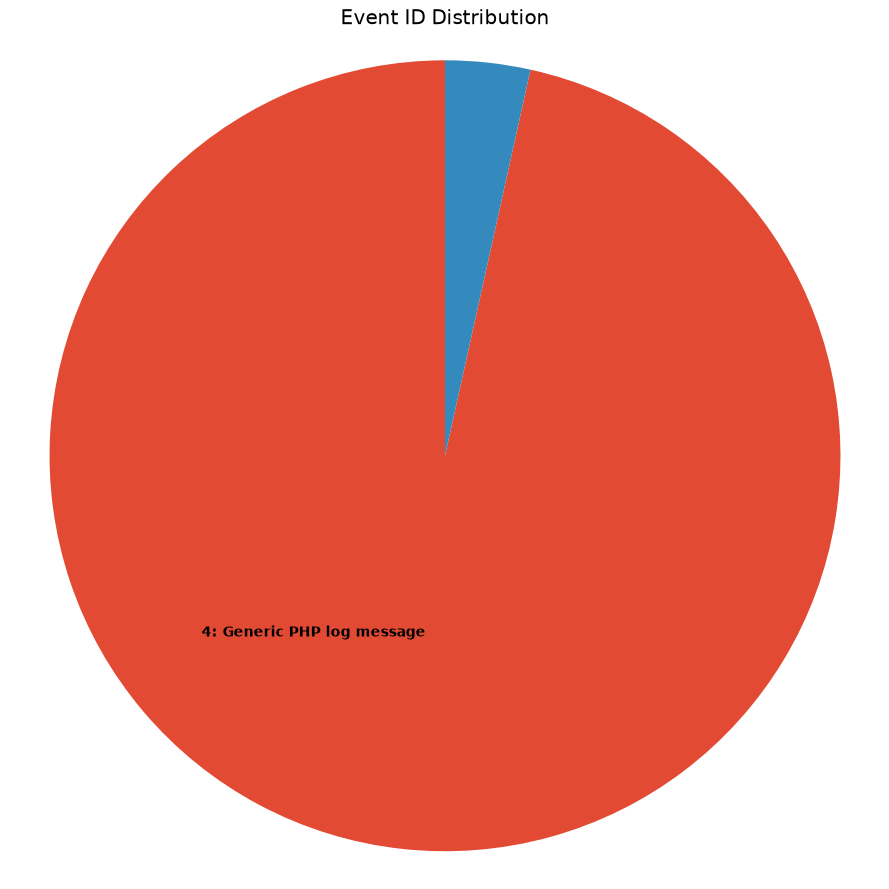

In [276]:
fig, ax = plt.subplots(figsize=(9, 9))

wedges, label_texts = ax.pie(
    frequent.values,
    labels=frequent.index,
    startangle=90,
    labeldistance=0.45,
)

# Make EventIDs bold
for t in label_texts:
    t.set_fontweight("bold")
    t.set_fontsize(10)

ax.set_title("Event ID Distribution")
ax.axis("equal")
plt.tight_layout()

plt.savefig(output_path / "event_id_distribution.png")

plt.show()

In [271]:
event_dfs = load_eventdata(evtx_path)

In [272]:
profiles = profile_all(event_dfs)

export_profiles_csv(profiles, output_path)

In [273]:
from contextlib import redirect_stdout

with open(output_path / 'profile_summary.txt', 'w') as f:
    with redirect_stdout(f):
        print_summary(profiles, event_dfs)

print_summary(profiles, event_dfs)


EventID 4 (20370 records)
  constant  : -
  >=95% null: ['Binary']
  variable  : ['Data_text']

EventID 64 (45 records)
  constant  : ['Context']
  >=95% null: -
  variable  : ['ObjId']

EventID 100 (7 records)
  constant  : -
  >=95% null: ['Binary']
  variable  : ['Data_text']

EventID 1000 (40 records)
  constant  : -
  >=95% null: ['Binary']
  variable  : ['Data_text']

EventID 1001 (57 records)
  constant  : -
  >=95% null: ['Binary']
  variable  : ['Data_text']

EventID 1704 (7 records)
  constant  : ['Data_text']
  >=95% null: ['Binary']
  variable  : -

EventID 4098 (69 records)
  constant  : ['Data_text']
  >=95% null: ['Binary']
  variable  : -

EventID 9027 (1 records)
  constant  : ['Data_text']
  >=95% null: ['Binary']
  variable  : -

EventID 16384 (253 records)
  constant  : -
  >=95% null: ['Binary']
  variable  : ['Data_text']

EventID 16394 (253 records)
  constant  : ['Data_text']
  >=95% null: ['Binary']
  variable  : -


In [274]:
constants = summarize_constants(profiles, event_dfs)

constants

{np.int64(4): {},
 np.int64(64): {'Context': 'Système local'},
 np.int64(100): {},
 np.int64(1000): {},
 np.int64(1001): {},
 np.int64(1704): {'Data_text': ''},
 np.int64(4098): {'Data_text': 'ordinateur | mrxsmb10 | GPO - Désactiver le protocole SMBv1 par les clefs de registre {AEA39459-2B7B-49ED-A066-9A0EA02E6EDC} | 0x80070057 Paramètre incorrect.'},
 np.int64(9027): {'Data_text': ''},
 np.int64(16384): {},
 np.int64(16394): {'Data_text': ''}}